# Data Preprocessing

This notebook prepares the SGCC Electricity Theft Detection dataset for machine learning.

Steps:
- Load dataset
- Explore missing values
- Remove duplicates
- Separate features and target
- Handle missing values
- Feature scaling
- Train-test split
- Save preprocessing objects

In [1]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import joblib

In [2]:
df = pd.read_csv("../data/data set.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (42372, 1036)


,1/1/2014,1/2/2014,1/3/2014,1/4/2014,1/5/2014,1/6/2014,1/7/2014,1/8/2014,1/9/2014,1/10/2014,...,10/24/2016,10/25/2016,10/26/2016,10/27/2016,10/28/2016,10/29/2016,10/30/2016,10/31/2016,CONS_NO,FLAG
0,0.0,0.0,0.01,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.02,0.06,0.58,0.89,0.35,0.38,0.70,0.25,0387DD8A07E07FDA6271170F86AD9151,1
1,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,17.13,14.32,16.37,26.33,19.06,17.38,13.94,14.14,01D6177B5D4FFE0CABA9EF17DAFC2B84,1
2,0.0,0.0,0.00,0.0,0.0,4.98,9.87,11.29,13.44,11.34,...,NaN,1.43,2.22,2.41,3.48,2.89,1.88,1.16,4B75AC4F2D8434CFF62DB64D0BB43103,1
3,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,20.98,18.47,15.50,14.80,19.28,16.10,17.51,16.67,B32AC8CC6D5D805AC053557AB05F5343,1
4,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.61,1.33,0.55,1.62,1.53,2.10,1.16,2.13,EDFC78B07BA2908B3395C4EB2304665E,1


Missing Values Visualization

In [3]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False).head(20)

10/3/2014    42357
3/19/2014    21505
2/28/2014    20985
3/4/2014     20820
3/3/2014     20806
4/19/2014    20633
2/20/2014    20536
2/23/2014    20494
2/24/2014    20326
3/2/2014     20224
3/1/2014     20207
2/27/2014    20165
2/25/2014    19917
2/21/2014    19883
2/26/2014    19880
4/9/2014     19607
2/22/2014    19594
8/8/2015     19450
3/23/2014    19377
3/26/2014    19318
dtype: int64

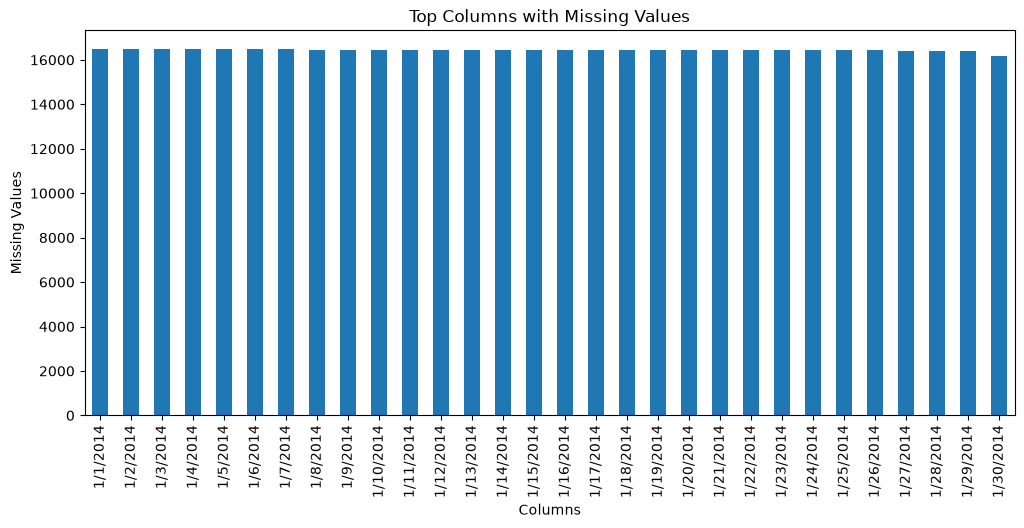

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

missing.head(30).plot(kind="bar")

plt.title("Top Columns with Missing Values")

plt.xlabel("Columns")

plt.ylabel("Missing Values")

plt.xticks(rotation=90)

plt.show()

In [5]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)
df = df.drop_duplicates()

print(df.shape)

Duplicate Records: 0
(42372, 1036)


In [6]:
X = df.drop(columns=["CONS_NO", "FLAG"])

y = df["FLAG"]

print(X.shape)

print(y.shape)

(42372, 1034)
(42372,)


In [7]:
imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("Remaining Missing Values:", X.isnull().sum().sum())

Remaining Missing Values: 0


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [10]:
print("Training Features :", X_train.shape)

print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)

print("Testing Labels    :", y_test.shape)

Training Features : (33897, 1034)
Testing Features  : (8475, 1034)
Training Labels   : (33897,)
Testing Labels    : (8475,)


In [13]:
print("Training Set Distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Set Distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training Set Distribution:
FLAG
0    91.468272
1     8.531728
Name: proportion, dtype: float64

Testing Set Distribution:
FLAG
0    91.469027
1     8.530973
Name: proportion, dtype: float64


Save Preprocessing Objects

In [11]:
joblib.dump(imputer, "../models/imputer.pkl")

joblib.dump(scaler, "../models/scaler.pkl")

print("Preprocessing objects saved successfully!")

Preprocessing objects saved successfully!


Save Processed Datasets

In [12]:
np.save("../models/X_train.npy", X_train)
np.save("../models/X_test.npy", X_test)

np.save("../models/y_train.npy", y_train)
np.save("../models/y_test.npy", y_test)

print("Processed datasets saved successfully!")

Processed datasets saved successfully!


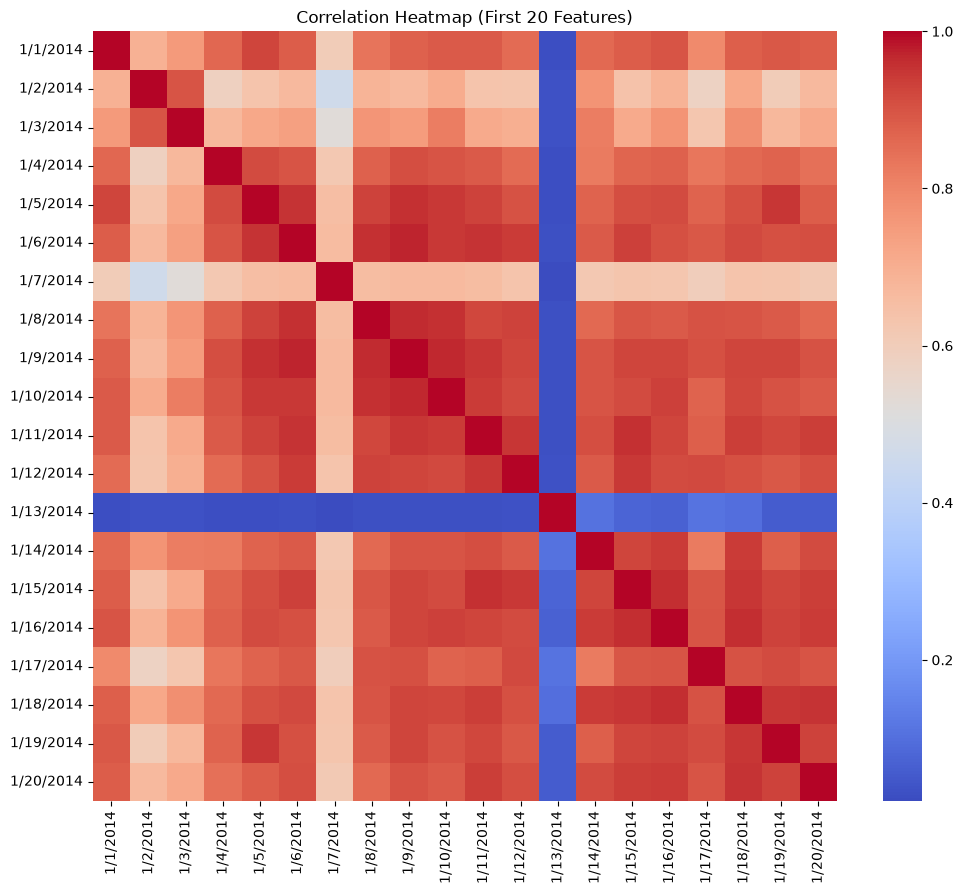

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sample_features = X.iloc[:, :20]

plt.figure(figsize=(12,10))
sns.heatmap(sample_features.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap (First 20 Features)")
plt.show()

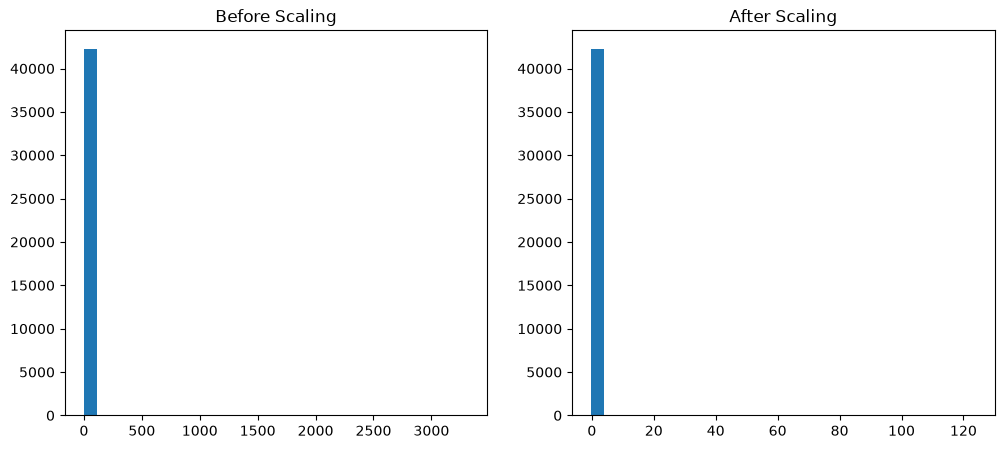

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(X.iloc[:,0], bins=30)
plt.title("Before Scaling")

plt.subplot(1,2,2)
plt.hist(X_scaled[:,0], bins=30)
plt.title("After Scaling")

plt.show()